# Politécnico Malvinas Argentinas- PDH: Preprocesamiento, Normalización y Técnicas Básicas

## Ejemplo básico en Python (sin librerías)

Este es el más simple para empezar:

In [ ]:
texto = "Hola mundo, esto es NLP"
tokens = texto.split()
print(tokens)

['Hola', 'mundo,', 'esto', 'es', 'NLP']


## Alternativa
- ✔ separa palabras
- ✔ separa puntuación

In [ ]:
import re

texto = "Hola mundo, esto es NLP."

tokens = re.findall(r'\w+|[^\w\s]', texto)

print(tokens)

['Hola', 'mundo', ',', 'esto', 'es', 'NLP', '.']


## Ejemplo con NLTK (mejor tokenización)

In [ ]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
from nltk.tokenize import word_tokenize

texto = "Hola mundo, esto es NLP."
tokens = word_tokenize(texto)

print(tokens)

['Hola', 'mundo', ',', 'esto', 'es', 'NLP', '.']


Este bloque instala la librería unidecode, que sirve para eliminar acentos y caracteres especiales de las palabras. El comando %%capture se usa para ocultar los mensajes de instalación, ideal si no querés que se llene la consola de texto mientras corrés el notebook.

**Convierte las palabras a minúsculas y les saca los acentos. . Esto ayuda a comparar palabras sin errores por tildes.**

In [ ]:
%%capture
!pip install unidecode

In [ ]:
import unidecode
[unidecode.unidecode(w.lower().strip()) for w in texto.split(' ')]

['hola', 'mundo,', 'esto', 'es', 'nlp.']

Con Regex podemos por ejemplo sacar comas

In [ ]:
import re
texto = "Hola mundo, esto es NLP."
texto_limpio = re.sub(r"[.,!?]", "", texto)
print(texto_limpio)

#text_clean = re.sub(r'[^a-zA-Záéíóúüñ ]', '', text.lower())
#print("Texto limpio con regex:", text_clean)

Hola mundo esto es NLP


## Ejemplo mas integral usando pipeline clásico de NLP:

- Tokenización
- Limpieza
- Análisis

In [ ]:
from nltk.tokenize import word_tokenize
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')

texto = "Hola mundo, esto es NLP."

tokens = word_tokenize(texto)

tokens_limpios = [t for t in tokens if t.isalnum()]

print(tokens_limpios)

['Hola', 'mundo', 'esto', 'es', 'NLP']


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


#Actividad

**texto = "Hola!!!, esto es genial, verdad?"**

Consigna:

- Tokenizar
- Sacar signos
- Mostrar resultado limpio

In [ ]:
#para el estudiante

#Stopwords (eliminar palabras sin valor)
Idea: sacar palabras como “el”, “la”, “es”, “de”

In [ ]:
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

texto = "Esto es un ejemplo simple de procesamiento de lenguaje"

tokens = word_tokenize(texto)

stop_words = set(stopwords.words('spanish'))

tokens_limpios = [t for t in tokens if t.lower() not in stop_words]

print(tokens_limpios)

['ejemplo', 'simple', 'procesamiento', 'lenguaje']


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


#Stemming (recortar palabras)

Reduce palabras a su raíz “aproximada”
- No es perfecto
- Pero es rápido

In [ ]:
from nltk.stem import SnowballStemmer

stemmer = SnowballStemmer('spanish')

palabras = ["corriendo", "corre", "corredor"]

stems = [stemmer.stem(p) for p in palabras]

print(stems)

['corr', 'corr', 'corredor']


#Lematización (forma correcta de la palabra)

- Más “inteligente” que stemming
- ⚠ En español con NLTK es limitado,

In [ ]:
import spacy
try:
    nlp = spacy.load("es_core_news_sm")
except:
    import os
    os.system("python -m spacy download es_core_news_sm")
    nlp = spacy.load("es_core_news_sm")
    import spacy

texto = "Los niños están corriendo en el parque"
doc = nlp(texto)
lemmas = [token.lemma_ for token in doc]
print(lemmas)

['el', 'niño', 'estar', 'correr', 'en', 'el', 'parque']


#Ejemplo INTEGRADOR

Pipeline completo simple

In [ ]:
import nltk
import re
import spacy

# Descargas necesarias
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nlp = spacy.load("es_core_news_sm")

texto = "Los alumnos están aprendiendo NLP, y están muy motivados!"

# 1. Tokenización
tokens = word_tokenize(texto)

# 2. Limpiar signos
tokens = [t for t in tokens if t.isalnum()]

# 3. Stopwords
stop_words = set(stopwords.words('spanish'))
tokens = [t for t in tokens if t.lower() not in stop_words]

# 4. Lematización
doc = nlp(" ".join(tokens))
lemmas = [token.lemma_ for token in doc]

print(lemmas)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


['alumno', 'aprender', 'NLP', 'motivado']


In [ ]:
print(lemmas)

['alumno', 'aprender', 'NLP', 'motivado']


#Consigna

Dado el siguiente texto:

texto = "Los estudiantes están aprendiendo NLP, y están muy motivados para programar!"

Realizar:

- Tokenizar el texto
- Eliminar signos de puntuación
- Eliminar stopwords en español
- Aplicar stemming
- Mostrar el resultado final

In [ ]:
#para el estudiante

#Levenshtein (distancia entre palabras)

- Mide cuántos cambios hay entre dos palabras
- Cantidad de errores entre dos palabras

In [ ]:
from Levenshtein import distance

palabra1 = "hola"
palabra2 = "holaa"

dist = distance(palabra1, palabra2)

print(dist)

#Fuzzy Matching (similitud)
- En lugar de contar errores, mide qué tan parecidos son

Usamos fuzzywuzzy:

In [ ]:
!pip install fuzzywuzzy
from fuzzywuzzy import fuzz

texto1 = "hola mundo"
texto2 = "hola mundoo"

similitud = fuzz.ratio(texto1, texto2)

print(similitud)

95


/usr/local/lib/python3.12/dist-packages/fuzzywuzzy/fuzz.py:11: UserWarning: Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning
  warnings.warn('Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning')


In [ ]:
print(similitud)

95


#Ejemplo integrador

In [ ]:
from fuzzywuzzy import fuzz
from nltk.tokenize import word_tokenize
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')

texto = "Juan Perez llegó tarde"
busqueda = "juan perez"

# Tokenizar
tokens = word_tokenize(texto.lower())

# Volver a armar texto limpio
texto_limpio = " ".join(tokens)

# Comparar
#similitud = fuzz.ratio(texto_limpio, busqueda)
#similitud = fuzz.partial_ratio(texto, busqueda)
#similitud = fuzz.token_set_ratio(texto_limpio, busqueda)


print("Similitud:", similitud)

if similitud > 80:
    print("Coincidencia encontrada")
else:
    print("No coincide")

Similitud: 100
Coincidencia encontrada


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


#No es lo mismo comparar frases completas que buscar si una está dentro de
| Método            | Cuándo usar                |
| ----------------- | -------------------------- |
| `ratio`           | textos iguales en longitud |
| `partial_ratio`   | uno está contenido en otro |
| `token_set_ratio` | NLP real (mejor opción)    |


In [ ]:
!pip install rapidfuzz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 25.6 MB/s eta 0:00:00


In [ ]:
from rapidfuzz import fuzz

texto = "juan perez llegó tarde"
busqueda = "juan perez"

similitud = fuzz.partial_ratio(texto, busqueda)

print(similitud)

100.0


In [ ]:
import difflib

texto = "juan perez llegó tarde"
busqueda = "juan perez"

similitud = difflib.SequenceMatcher(None, texto, busqueda).ratio()

print(similitud)

0.625


In [ ]:
if busqueda in texto:
    print("Coincidencia encontrada")
else:
    print("No coincide")

Coincidencia encontrada


In [ ]:
print("ratio:", fuzz.ratio(texto, busqueda))
print("partial:", fuzz.partial_ratio(texto, busqueda))
print("token_set:", fuzz.token_set_ratio(texto, busqueda))

ratio: 62.5
partial: 100.0
token_set: 100.0


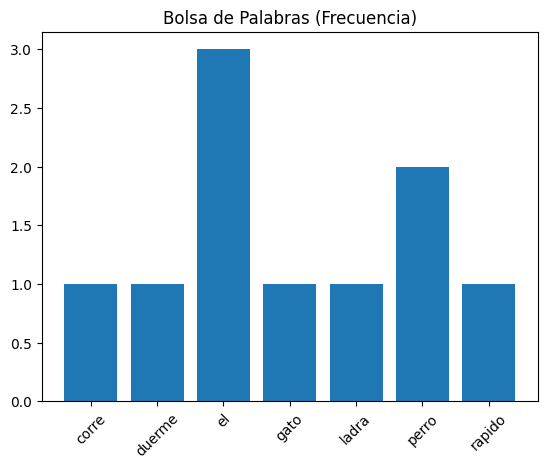

In [ ]:
# BoW and TF-IDF example with simple plots (no color specified)
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import matplotlib.pyplot as plt
# Text corpus
docs = [
    "el perro corre rapido",
    "el perro ladra",
    "el gato duerme"
]

# --- Bag of Words ---
bow = CountVectorizer()
X_bow = bow.fit_transform(docs)

words = bow.get_feature_names_out()
counts = X_bow.toarray().sum(axis=0)

# Plot BoW
plt.figure()
plt.bar(words, counts)
plt.title("Bolsa de Palabras (Frecuencia)")
plt.xticks(rotation=45)
plt.show()



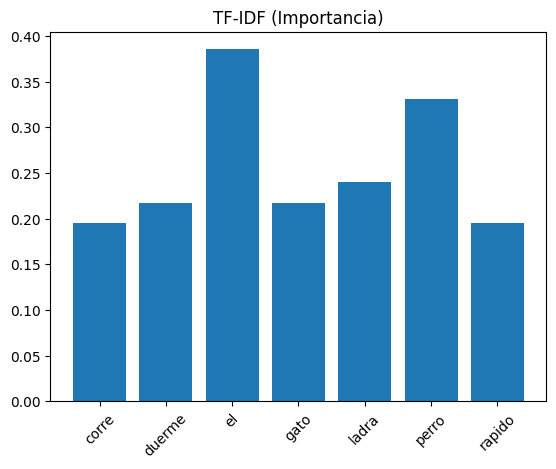

In [ ]:
# --- TF-IDF ---
tfidf = TfidfVectorizer()
X_tfidf = tfidf.fit_transform(docs)

words_tfidf = tfidf.get_feature_names_out()
values = X_tfidf.toarray().mean(axis=0)

# Plot TF-IDF
plt.figure()
plt.bar(words_tfidf, values)
plt.title("TF-IDF (Importancia)")
plt.xticks(rotation=45)
plt.show()

#Bolsa de Palabras (BoW)

- Cuenta cuántas veces aparece cada palabra

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

docs = [
    "el perro corre rapido",
    "el perro ladra",
    "el gato duerme"
]

vectorizer = CountVectorizer()
X = vectorizer.fit_transform(docs)

print(vectorizer.get_feature_names_out())
print(X.toarray())

['corre' 'duerme' 'el' 'gato' 'ladra' 'perro' 'rapido']
[[1 0 1 0 0 1 1]
 [0 0 1 0 1 1 0]
 [0 1 1 1 0 0 0]]


#TF-IDF

- Mide qué tan importante es una palabra

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(docs)

print(vectorizer.get_feature_names_out())
print(X.toarray())

['corre' 'duerme' 'el' 'gato' 'ladra' 'perro' 'rapido']
[[0.5844829  0.         0.34520502 0.         0.         0.44451431
  0.5844829 ]
 [0.         0.         0.42544054 0.         0.72033345 0.54783215
  0.        ]
 [0.         0.65249088 0.38537163 0.65249088 0.         0.
  0.        ]]


#📊 ¿Qué muestran los gráficos que viste?
##🔵 BoW
“el” aparece muchas veces → valor alto
- ❌ pero no aporta significado
##🟢 TF-IDF
“el” pierde peso
- ✔ “corre”, “ladra”, “duerme” ganan importancia
##🎯 DIFERENCIA CLAVE (para decir en clase)
Método	Qué hace	Problema
- BoW	Cuenta palabras	No distingue importancia
- TF-IDF	Pondera palabras	✔ Más inteligente

#Caso de Estudio 1: Analisis de sentimiento
Clasificar textos como:

😊 Positivo
😠 Negativo

##Corpus

In [ ]:
texts = [
    "Me encanta este producto, es excelente",
    "Muy buena calidad y atención",
    "Estoy feliz con la compra",
    "Funciona perfecto, lo recomiendo",
    "Es una experiencia maravillosa",

    "No me gustó para nada",
    "Muy mala calidad",
    "Estoy decepcionado",
    "no es tan bueno",
    "Una experiencia horrible"
]

labels = [
    "positivo","positivo","positivo","positivo","positivo",
    "negativo","negativo","negativo","negativo","negativo"
]

In [ ]:
#Vectorizacion TF-IF
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(texts)

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X, labels)

LogisticRegression()

In [ ]:
nuevos = [
    "me encanta este lugar",
    "es horrible no lo recomiendo",
    "muy buena experiencia",
    "no me gustó",
    #"no es tan bueno",
    # "no, es tan bueno!"
]

X_test = vectorizer.transform(nuevos)
predicciones = model.predict(X_test)

for texto, pred in zip(nuevos, predicciones):
    print(texto, "→", pred)

me encanta este lugar → positivo
es horrible no lo recomiendo → negativo
muy buena experiencia → positivo
no me gustó → negativo


In [ ]:
print(vectorizer.get_feature_names_out())

['atención' 'bien' 'buena' 'calidad' 'compra' 'con' 'decepcionado'
 'encanta' 'es' 'este' 'estoy' 'excelente' 'experiencia' 'feliz'
 'funciona' 'gustó' 'horrible' 'la' 'lo' 'mala' 'maravillosa' 'me' 'muy'
 'nada' 'no' 'para' 'perfecto' 'producto' 'recomiendo' 'una']


##Reflexionemos

¿Qué pasa si pongo: “no es tan bueno”?
Ahí aparece:
- ambigüedad
- límite del modelo

Caso de Estudio 1 BIS: Analisis de sentimiento

In [ ]:
#from google.colab import files
#files.upload()

In [ ]:
import os
print(os.listdir("/content"))

['.config', 'alumnos.xlsx', 'sample_data']


In [ ]:
import pandas as pd

ruta = "/content/resenasES.xlsx"
df = pd.read_excel(ruta)
print(df.head())


                                           review_es sentimiento
0  Uno de los otros críticos ha mencionado que de...    positivo
1  Una pequeña pequeña producción.La técnica de f...    positivo
2  Pensé que esta era una manera maravillosa de p...    positivo
3  Básicamente, hay una familia donde un niño peq...    negativo
4  El "amor en el tiempo" de Petter Mattei es una...    positivo


In [ ]:
df_original = df.copy()

In [ ]:
# Limpiar datos
df["sentimiento"] = df["sentimiento"].str.strip().str.lower()

In [ ]:
import re

df["sentimiento"] = df["sentimiento"].apply(lambda x: re.sub(r"[^\w\s]", "", str(x)))

In [ ]:
print(df_original["sentimiento"].unique())

['positivo' 'negativo' 'POSITIVO' 'negativo.']


In [ ]:
print("Antes:", df_original["sentimiento"].unique())
print("Después:", df["sentimiento"].unique())

Antes: ['positivo' 'negativo' 'POSITIVO' 'negativo.']
Después: ['positivo' 'negativo' 'negativo.']


In [ ]:
#print("Antes de limpiar:", len(df_original))
#print("Después de limpiar:", len(df))

In [ ]:
#print("Antes:")
#rint(df_original["sentimiento"].value_counts())

#print("\nDespués:")
#print(df["sentimiento"].value_counts())

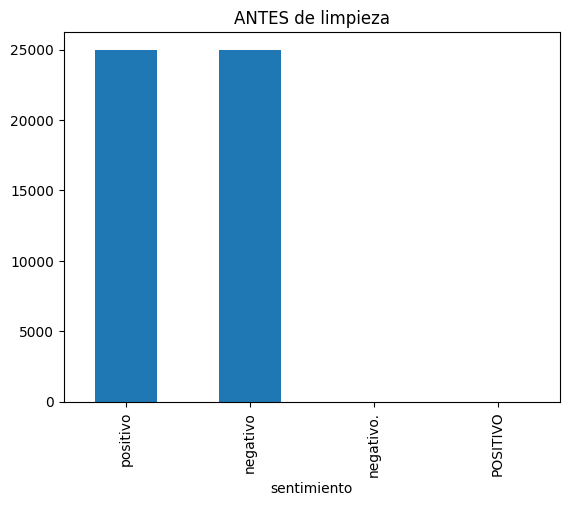

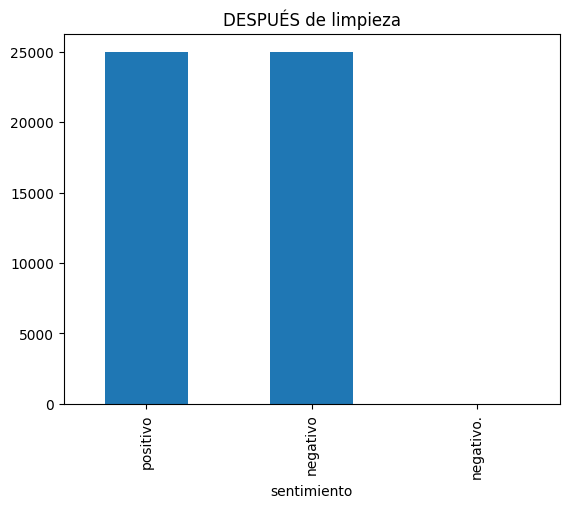

In [ ]:
import matplotlib.pyplot as plt

# Antes (sin limpiar)
antes = df_original["sentimiento"].value_counts()

plt.figure()
antes.plot(kind='bar')
plt.title("ANTES de limpieza")
plt.show()

# Después (limpio)
despues = df["sentimiento"].value_counts()
plt.figure()
despues.plot(kind='bar')
plt.title("DESPUÉS de limpieza")
plt.show()



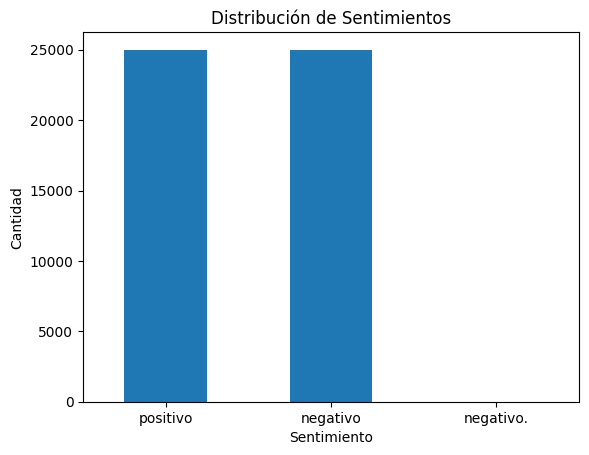

In [ ]:
# Create a simple visualization of sentiment distribution
#import pandas as pd
#import matplotlib.pyplot as plt

# Load the dataset
#df = pd.read_excel('/content/resenasES.xlsx')

# Clean data
df = df.dropna()
df["sentimiento"] = df["sentimiento"].str.strip()

# Count sentiments
conteo = df["sentimiento"].value_counts()

# Plot
plt.figure()
conteo.plot(kind='bar')
plt.title("Distribución de Sentimientos")
plt.xlabel("Sentimiento")
plt.ylabel("Cantidad")
plt.xticks(rotation=0)
plt.show()

In [ ]:
# Preparar datos
texts = df["review_es"].astype(str).tolist()
labels = [1 if l == "positivo" else 0 for l in df["sentimiento"]]

In [ ]:
print(texts[:3])

['Uno de los otros críticos ha mencionado que después de ver solo 1 Oz Episodio, estará enganchado. Tienen razón, ya que esto es exactamente lo que sucedió conmigo. La primera cosa que me golpeó sobre Oz fue su brutalidad y sus escenas de violencia inconfiadas, que se encuentran a la derecha de la palabra. Confía en mí, este no es un espectáculo para los débiles de corazón o tímido. Este espectáculo no extrae punzones con respecto a las drogas, el sexo o la violencia. Es Hardcore, en el uso clásico de la palabra. Se llama OZ, ya que es el apodo dado al Penitenciario del Estado de Seguridad Máximo de Oswald. Se centra principalmente en la ciudad de Emeralda, una sección experimental de la prisión donde todas las células tienen frentes de vidrio y se enfrentan hacia adentro, por lo que la privacidad no es alta en la agenda. Em City es el hogar de muchos ... Fariarios, musulmanes, gangstas, latinos, cristianos, italianos, irlandeses y más ... así que las esposas, las miradas de muerte, la

In [ ]:
print(labels[:10])

[1, 1, 1, 0, 1, 1, 1, 0, 0, 1]


In [ ]:
# Vectorización
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=1000)
X = vectorizer.fit_transform(texts)

In [ ]:
print(X)
print(X.shape)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 3962219 stored elements and shape (50000, 1000)>
  Coords	Values
  (0, 928)	0.042879409714257286
  (0, 178)	0.3729766457703225
  (0, 511)	0.12373775807940293
  (0, 646)	0.10907392936687847
  (0, 392)	0.04226155024100553
  (0, 742)	0.2712512764089468
  (0, 198)	0.04263629540498648
  (0, 948)	0.03508638596243134
  (0, 832)	0.06674318624276135
  (0, 267)	0.14835612112094654
  (0, 894)	0.11270379820083151
  (0, 752)	0.06004578199502972
  (0, 989)	0.0842580944134875
  (0, 317)	0.034191614482797714
  (0, 273)	0.15640943177653963
  (0, 332)	0.07458066494446544
  (0, 507)	0.06779554728433833
  (0, 845)	0.08293850121676366
  (0, 485)	0.2348255558463093
  (0, 716)	0.05202714572098801
  (0, 156)	0.057009570116731495
  (0, 538)	0.09418498207492969
  (0, 830)	0.03758368424023738
  (0, 360)	0.06543196178632188
  (0, 843)	0.050701032176086985
  :	:
  (49999, 998)	0.11710012534031179
  (49999, 91)	0.09075871055588032
  (49999, 671)	0.133255

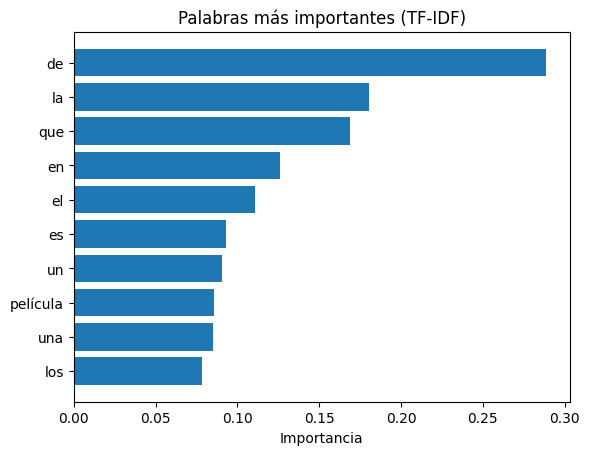

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Obtener palabras
palabras = vectorizer.get_feature_names_out()

# Promedio de importancia TF-IDF
valores = X.mean(axis=0).A1

# Top 10 palabras
top_indices = np.argsort(valores)[-10:]

top_palabras = palabras[top_indices]
top_valores = valores[top_indices]

# Gráfico
plt.figure()
plt.barh(top_palabras, top_valores)
plt.title("Palabras más importantes (TF-IDF)")
plt.xlabel("Importancia")
plt.show()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


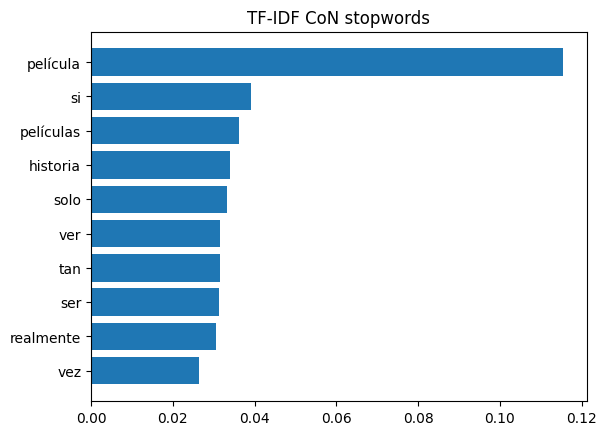

In [ ]:
import nltk
nltk.download('stopwords')

from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer

stop_words = stopwords.words('spanish')

vectorizer_sw = TfidfVectorizer(
    max_features=1000,
    stop_words=stop_words
)

X_sw = vectorizer_sw.fit_transform(texts)

import numpy as np
import matplotlib.pyplot as plt

palabras = vectorizer_sw.get_feature_names_out()
valores = X_sw.mean(axis=0).A1

top_indices = np.argsort(valores)[-10:]

plt.figure()
plt.barh(palabras[top_indices], valores[top_indices])
plt.title("TF-IDF CoN stopwords")
plt.show()

In [ ]:
# Modelo
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X, labels)

LogisticRegression(max_iter=1000)

In [ ]:
# Prueba
test = [
    "me encantó la película",
    "es horrible no me gustó",
    "muy buena historia"
]

X_test = vectorizer.transform(test)
print(model.predict(X_test))


[1 0 1]


In [ ]:
preds = model.predict(X_test)
for texto, pred in zip(test, preds):
    sentimiento = "positivo" if pred == 1 else "negativo"
    print(f"{texto} → {sentimiento}")

me encantó la película → positivo
es horrible no me gustó → negativo
muy buena historia → positivo


In [ ]:
texto = input("Dejanos tu opinión")

X_test = vectorizer.transform([texto])
pred = model.predict(X_test)[0]

sentimiento = "positivo" if pred == 1 else "negativo"

print("Resultado:", sentimiento)

Dejanos tu opiniónhoal
Resultado: positivo


In [ ]:
print(vectorizer.get_feature_names_out()[:20])

['10' '20' '30' '70' '80' '90' 'about' 'absolutamente' 'absoluto'
 'aburrida' 'aburrido' 'acción' 'acerca' 'actor' 'actores' 'actriz'
 'actuaciones' 'actuación' 'actuando' 'actuar']


In [ ]:
!pip install wordcloud


This dataset contains tweets in Spanish labeled for sentiment. You can explore its structure and use it for your sentiment analysis tasks.

#Caso de estudio 2: Asistencia de Alumnos
Problema: los nombres no siempre coinciden exactamente  
Solución: usar similitud de texto


##Excel oficial → Excel asistencia → NLP → Resultado final

In [ ]:
# carga de listado oficial
df_base = pd.read_excel("alumnos.xlsx")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
print(df_base)
print(df_base.head())


             Nombre             Apellido  \
0      Coordinación            Académica   
1             Elias             Albornoz   
2           Gabriel              Bellesi   
3           Mariano                 Buet   
4            Ismael              Caiazza   
5         Guillermo              Carcamo   
6     Nancy Julieta              Cassano   
7     Melani Yohana              Caucota   
8             Marta                 Cruz   
9     Matias Daniel            Espindola   
10           Gisela               Fariaz   
11           Marcos               Farina   
12        Ana María            Fernández   
13    Darío Agustín       García Barquet   
14         Carolina           Godoy Leal   
15    Alina Eleonor             Gonzalez   
16            Diego             González   
17            Ariel               Gualla   
18    Mariana Anahi                Lopez   
19      Politecnico  Malvinas Argentinas   
20        Rectorado  Malvinas Argentinas   
21  Gustavo gabriel             

In [ ]:
#carga de asistencia
df_asistencia = pd.read_excel("asistencia.xlsx")

In [ ]:
# “Unimos nombre y apellido y lo pasamos todo a minúsculas para comparar mejor.”
df_base["nombre_completo"] = (
    df_base["Nombre"] + " " + df_base["Apellido"]
).str.lower().str.strip()

In [ ]:
print(df_base["nombre_completo"])

0              coordinación académica
1                      elias albornoz
2                     gabriel bellesi
3                        mariano buet
4                      ismael caiazza
5                   guillermo carcamo
6               nancy julieta cassano
7               melani yohana caucota
8                          marta cruz
9             matias daniel espindola
10                      gisela fariaz
11                      marcos farina
12                ana maría fernández
13       darío agustín garcía barquet
14                carolina godoy leal
15             alina eleonor gonzalez
16                     diego gonzález
17                       ariel gualla
18                mariana anahi lopez
19    politecnico malvinas argentinas
20      rectorado malvinas argentinas
21           gustavo gabriel mansilla
22                    martín mirabete
23               silvana paez jimenez
24                tutoras politecnico
25                     valeria rivero
26          

In [ ]:
#para asistencia idem
df_asistencia["nombre_completo"] = df_asistencia["Nombre"] + " " + df_asistencia["Apellido"]

df_asistencia["nombre_completo"] = df_asistencia["nombre_completo"].str.lower()

df_asistencia["nombre_completo"] = df_asistencia["nombre_completo"].str.strip()

In [ ]:
print(df_asistencia["nombre_completo"])

0                         juan torres
1                      elias albornoz
2                     gabriel bellesi
3                        mariano buet
4                      isamel caiazza
5                   guillermo carcamo
6               nancy julieta cassano
7               melani yohana caucota
8                          marta cruz
9                    matias espindola
10                      gisela fariaz
11                      marcos farina
12                     ana  fernandez
13       darío agustín garcía barquet
14                carolina godoy leal
15                    alina  gonzalez
16                     diefo gonzalez
17                       ariel gualla
18                     mariana  lopez
19    politecnico malvinas argentinas
20      rectorado malvinas argentinas
21           gustavo gabriel mansilla
22                    martín mirabete
23              silvna  paez jiemenez
24                tutoras politecnico
25                     valeria rivero
26          

In [ ]:
print(df_base["Nombre"].iloc[0])
print(df_base["nombre_completo"].iloc[0])

Coordinación
coordinación académica


In [ ]:
#comparacion de similitud

!pip install rapidfuzz
from rapidfuzz import fuzz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 80.6 MB/s eta 0:00:00


In [ ]:
#print(df_base[["nombre", "apellido", "estado"]])
df_base["estado"] = "ausente"
print(df_base[["nombre_completo", "estado"]])

In [ ]:
from rapidfuzz import fuzz

lista_asistencia = df_asistencia["nombre_completo"].tolist()

estados = []

for nombre in df_base["nombre_completo"]:
    encontrado = "ausente"

    for alumno in lista_asistencia:
        if fuzz.token_sort_ratio(nombre, alumno) > 70:
            encontrado = "presente"
            break

    estados.append(encontrado)

df_base["estado"] = estados

In [ ]:
print(df_base[["nombre_completo", "estado"]])

#Reflexión final

Este método no es perfecto, pero permite manejar errores reales.